Exp 11. To predict whether a person has diabetes based on features such as blood
pressure, skin thickness, age, etc., using the bagging ensemble technique. Also
perform comparative analysis among the bagging classifier, random forest, and the
decision tree classifier.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score

# Models

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier

In [ ]:
# Load dataset
data = pd.read_csv("/content/drive/MyDrive/python-ml-lab/exp_11_12/dataset_diabetes_exp_11.csv")
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
data.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [ ]:
for col in ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']:
    print(f"Number of 0 values in {col}: {len(data[data[col] == 0])}")

Number of 0 values in Glucose: 5
Number of 0 values in BloodPressure: 35
Number of 0 values in SkinThickness: 227
Number of 0 values in Insulin: 374
Number of 0 values in BMI: 11


In [ ]:
# Replace 0 values with the median of the respective column
for col in ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']:
    data[col] = data[col].replace(0, data[col].median())

# Verify that 0 values have been replaced
for col in ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']:
    print(f"Number of 0 values in {col} after imputation: {len(data[data[col] == 0])}")

display(data.head())

Number of 0 values in Glucose after imputation: 0
Number of 0 values in BloodPressure after imputation: 0
Number of 0 values in SkinThickness after imputation: 0
Number of 0 values in Insulin after imputation: 0
Number of 0 values in BMI after imputation: 0


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,30.5,33.6,0.627,50,1
1,1,85,66,29,30.5,26.6,0.351,31,0
2,8,183,64,23,30.5,23.3,0.672,32,1
3,1,89,66,23,94.0,28.1,0.167,21,0
4,0,137,40,35,168.0,43.1,2.288,33,1


In [ ]:
# Separate features (X) and target (y)
X = data.drop('Outcome', axis=1)
y = data['Outcome']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (614, 8)
Shape of X_test: (154, 8)
Shape of y_train: (614,)
Shape of y_test: (154,)


In [ ]:
# Scale numerical features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

display(X_train_scaled.head())

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,-0.851355,-1.056427,-0.826740,-1.649322,-0.512280,-0.768811,0.310794,-0.792169
1,0.356576,0.144399,0.477772,-0.035741,-0.727129,-0.416841,-0.116439,0.561034
2,-0.549372,-0.556083,-1.152868,1.362697,0.009498,0.360425,-0.764862,-0.707594
3,-0.851355,0.811525,-1.315932,-0.466029,-0.640166,-0.402176,0.262314,-0.369293
4,-1.153338,-0.889646,-0.663676,1.255125,0.122038,1.782968,-0.337630,-0.961320


In [ ]:
print("\n--- Training All Models ---\n")

RF = RandomForestClassifier(n_estimators=100, random_state=42)
RF.fit(X_train_scaled, y_train)
print("Random Forest model trained.")

DT = DecisionTreeClassifier(random_state=42)
DT.fit(X_train_scaled, y_train)
print("Decision Tree model trained.")


bagging_classifier = BaggingClassifier(random_state=42)
bagging_classifier.fit(X_train_scaled, y_train)
print("Bagging Classifier model trained.")



--- Training All Models ---

Random Forest model trained.
Decision Tree model trained.
Bagging Classifier model trained.


### 1. Decision Tree Classifier

In [ ]:
# Initialize and train the Decision Tree Classifier
dt_classifier = DecisionTreeClassifier(random_state=42)
dt_classifier.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred_dt = dt_classifier.predict(X_test_scaled)

# Evaluate the Decision Tree Classifier
print("Decision Tree Classifier Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")
print(classification_report(y_test, y_pred_dt))

Decision Tree Classifier Performance:
Accuracy: 0.6688
              precision    recall  f1-score   support

           0       0.72      0.79      0.76       100
           1       0.53      0.44      0.48        54

    accuracy                           0.67       154
   macro avg       0.63      0.62      0.62       154
weighted avg       0.66      0.67      0.66       154



### 2. Random Forest Classifier

In [ ]:
# Initialize and train the Random Forest Classifier
rf_classifier = RandomForestClassifier(random_state=42)
rf_classifier.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred_rf = rf_classifier.predict(X_test_scaled)

# Evaluate the Random Forest Classifier
print("Random Forest Classifier Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(classification_report(y_test, y_pred_rf))

Random Forest Classifier Performance:
Accuracy: 0.7597
              precision    recall  f1-score   support

           0       0.79      0.85      0.82       100
           1       0.68      0.59      0.63        54

    accuracy                           0.76       154
   macro avg       0.74      0.72      0.73       154
weighted avg       0.75      0.76      0.76       154



### 3. Bagging Classifier

In [ ]:
# Make predictions on the test set
y_pred_bag = bagging_classifier.predict(X_test_scaled)

# Evaluate the Bagging Classifier
print("Bagging Classifier Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_bag):.4f}")
print(classification_report(y_test, y_pred_bag))

Bagging Classifier Performance:
Accuracy: 0.7403
              precision    recall  f1-score   support

           0       0.78      0.84      0.81       100
           1       0.65      0.56      0.60        54

    accuracy                           0.74       154
   macro avg       0.71      0.70      0.70       154
weighted avg       0.73      0.74      0.73       154



### Comparative Analysis of Model Performance

### Confusion Matrix for Decision Tree Classifier

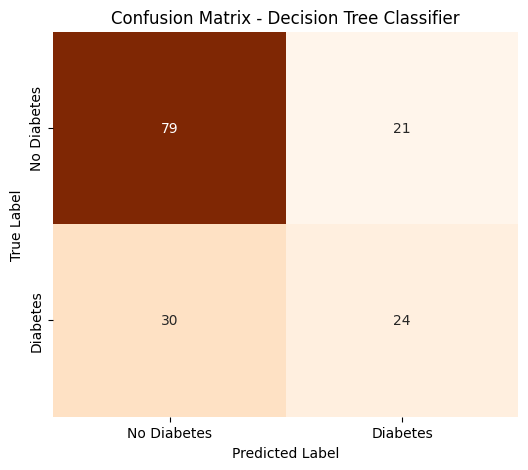

In [ ]:
cm_dt = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Oranges', cbar=False,
            xticklabels=['No Diabetes', 'Diabetes'], yticklabels=['No Diabetes', 'Diabetes'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Decision Tree Classifier')
plt.show()

### Confusion Matrix for Random Forest Classifier

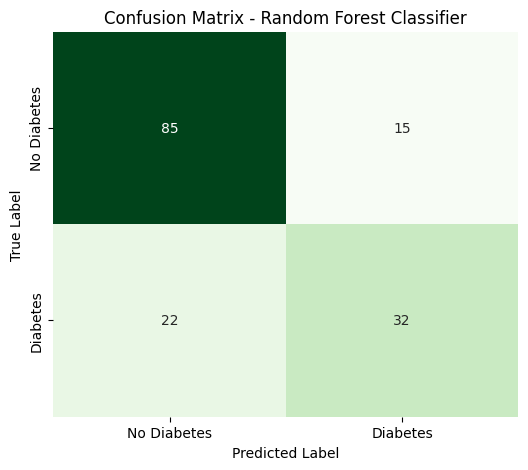

In [ ]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['No Diabetes', 'Diabetes'], yticklabels=['No Diabetes', 'Diabetes'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Random Forest Classifier')
plt.show()

### Confusion Matrix for Bagging Classifier

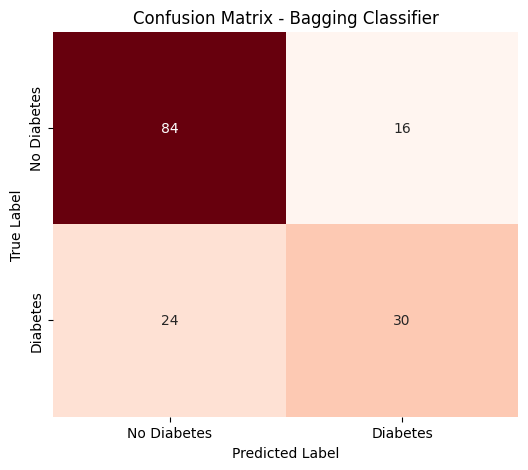

In [ ]:
cm_bag = confusion_matrix(y_test, y_pred_bag)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_bag, annot=True, fmt='d', cmap='Reds', cbar=False,
            xticklabels=['No Diabetes', 'Diabetes'], yticklabels=['No Diabetes', 'Diabetes'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Bagging Classifier')
plt.show()

,Model,Accuracy,Precision,Recall,F1-Score
0,Decision Tree,0.6688,0.5333,0.4444,0.4848
1,Random Forest,0.7597,0.6809,0.5926,0.6337
2,Bagging Classifier,0.7403,0.6522,0.5556,0.6000


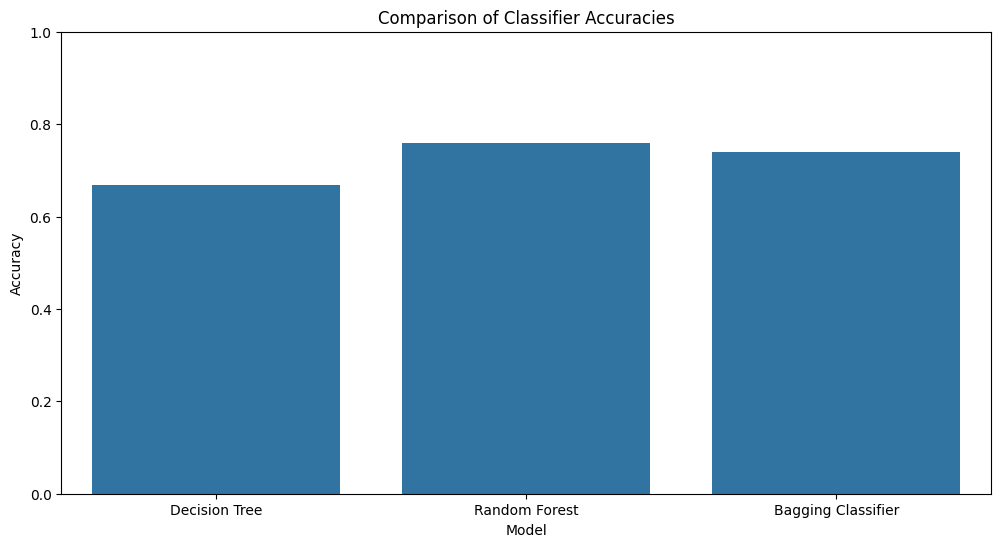

In [ ]:
models = ['Decision Tree', 'Random Forest', 'Bagging Classifier']
accuracies = [
    accuracy_score(y_test, y_pred_dt),
    accuracy_score(y_test, y_pred_rf),
    accuracy_score(y_test, y_pred_bag)
]

precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)

precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

precision_bag = precision_score(y_test, y_pred_bag)
recall_bag = recall_score(y_test, y_pred_bag)
f1_bag = f1_score(y_test, y_pred_bag)

metrics_df = pd.DataFrame({
    'Model': models,
    'Accuracy': accuracies,
    'Precision': [precision_dt, precision_rf, precision_bag],
    'Recall': [recall_dt, recall_rf, recall_bag],
    'F1-Score': [f1_dt, f1_rf, f1_bag]
})

display(metrics_df.round(4))

# Visualize the comparison
plt.figure(figsize=(12, 6))
sns.barplot(x='Model', y='Accuracy', data=metrics_df)
plt.title('Comparison of Classifier Accuracies')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.show()

/tmp/ipykernel_13011/3479719159.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='F1-Score', data=metrics_df, palette='viridis')


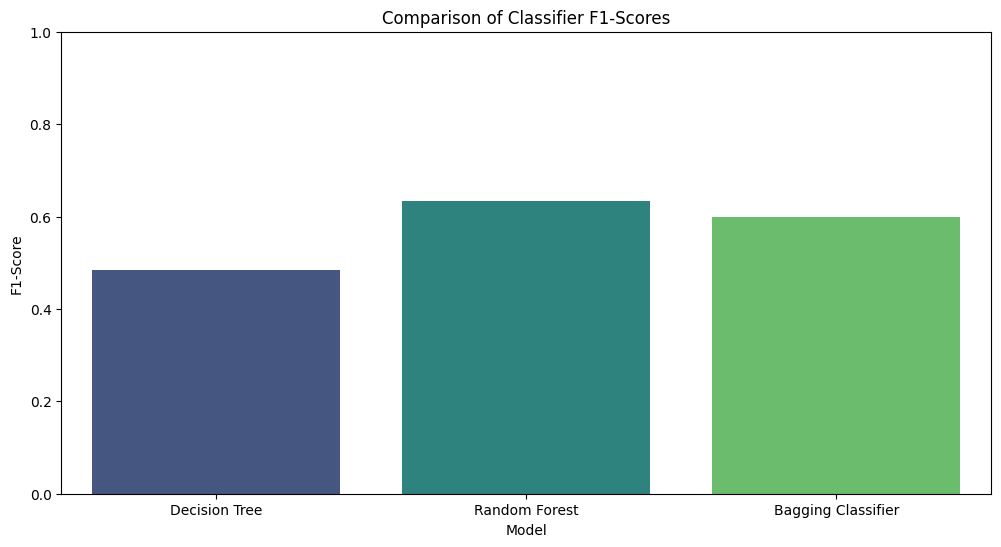

In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(x='Model', y='F1-Score', data=metrics_df, hue='Model', palette='viridis', legend=False)
plt.title('Comparison of Classifier F1-Scores')
plt.ylabel('F1-Score')
plt.ylim(0, 1)
plt.show()

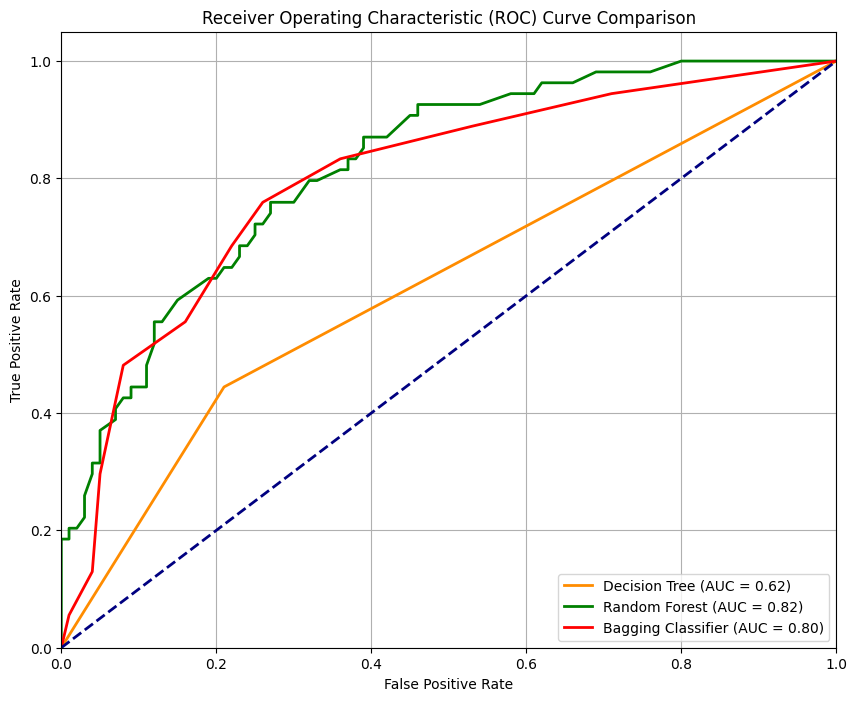

In [ ]:
from sklearn.metrics import roc_curve, auc

# Predict probabilities for the positive class
y_pred_proba_dt = dt_classifier.predict_proba(X_test_scaled)[:, 1]
y_pred_proba_rf = rf_classifier.predict_proba(X_test_scaled)[:, 1]
y_pred_proba_bag = bagging_classifier.predict_proba(X_test_scaled)[:, 1]

# Calculate ROC curve and AUC for Decision Tree
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_pred_proba_dt)
roc_auc_dt = auc(fpr_dt, tpr_dt)

# Calculate ROC curve and AUC for Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

# Calculate ROC curve and AUC for Bagging Classifier
fpr_bag, tpr_bag, _ = roc_curve(y_test, y_pred_proba_bag)
roc_auc_bag = auc(fpr_bag, tpr_bag)

# Plot ROC curves
plt.figure(figsize=(10, 8))
plt.plot(fpr_dt, tpr_dt, color='darkorange', lw=2, label=f'Decision Tree (AUC = {roc_auc_dt:.2f})')
plt.plot(fpr_rf, tpr_rf, color='green', lw=2, label=f'Random Forest (AUC = {roc_auc_rf:.2f})')
plt.plot(fpr_bag, tpr_bag, color='red', lw=2, label=f'Bagging Classifier (AUC = {roc_auc_bag:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve Comparison')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [ ]:
import pickle
import os

# Create a directory to save the models if it doesn't exist
model_dir = 'trained_models'
os.makedirs(model_dir, exist_ok=True)

# Save the Decision Tree Classifier model
with open(os.path.join(model_dir, 'decision_tree_classifier.pkl'), 'wb') as f:
    pickle.dump(DT, f)
print("Decision Tree Classifier saved as 'decision_tree_classifier.pkl'")

# Save the Random Forest Classifier model
with open(os.path.join(model_dir, 'random_forest_classifier.pkl'), 'wb') as f:
    pickle.dump(RF, f)
print("Random Forest Classifier saved as 'random_forest_classifier.pkl'")

# Save the Bagging Classifier model
with open(os.path.join(model_dir, 'bagging_classifier.pkl'), 'wb') as f:
    pickle.dump(bagging_classifier, f)
print("Bagging Classifier saved as 'bagging_classifier.pkl'")

Decision Tree Classifier saved as 'decision_tree_classifier.pkl'
Random Forest Classifier saved as 'random_forest_classifier.pkl'
Bagging Classifier saved as 'bagging_classifier.pkl'
